Name: Ashwini Aher

Cnum: PEC2026101

Subject: Machine Learning

Assignment 3: (For Simple Linear Regration)

1. Implement simple linear regression analyses on the dataset.

2. Evaluate the models' performance based on MSE, RMSE, and R2 scores.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# STEP 1: Load the dataset
df = pd.read_csv('01Students.csv')
print("Step 1: Data loaded")
print(df.head())
print()

Step 1: Data loaded
   Hours  Marks
0      0     34
1      1     36
2      1     33
3      1     39
4      1     42



In [ ]:
# STEP 2: Prepare features (X) and target (y)
# sklearn expects X to be 2D (n_samples, n_features)
X = df[['Hours']].values   # 2D array, shape (n, 1)
y = df['Marks'].values     # 1D array, shape (n,)

print("Step 2: Feature/target shapes")
print(f"X shape = {X.shape}, y shape = {y.shape}")
print()


Step 2: Feature/target shapes
X shape = (30, 1), y shape = (30,)



In [ ]:
# STEP 3: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Step 3: Train/test split")
print(f"Training samples = {len(X_train)}, Test samples = {len(X_test)}")
print()

Step 3: Train/test split
Training samples = 24, Test samples = 6



In [ ]:
# STEP 4: Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Step 4: Model fitted")
print(f"Slope (coef_)      = {model.coef_[0]:.4f}")
print(f"Intercept (intercept_) = {model.intercept_:.4f}")
print(f"Regression equation: Marks = {model.intercept_:.3f} + {model.coef_[0]:.3f} * Hours")
print()

Step 4: Model fitted
Slope (coef_)      = 4.9885
Intercept (intercept_) = 34.9748
Regression equation: Marks = 34.975 + 4.988 * Hours



In [ ]:
# STEP 5: Predict on the test set
y_pred = model.predict(X_test)

print("Step 5: Predictions on test set")
for actual, pred, hrs in zip(y_test, y_pred, X_test.flatten()):
    print(f"Hours={hrs:>2}  Actual={actual:>3}  Predicted={pred:.2f}")
print()


Step 5: Predictions on test set
Hours=10  Actual= 81  Predicted=84.86
Hours= 5  Actual= 59  Predicted=59.92
Hours= 8  Actual= 89  Predicted=74.88
Hours= 6  Actual= 71  Predicted=64.91
Hours= 3  Actual= 53  Predicted=49.94
Hours= 3  Actual= 46  Predicted=49.94



In [ ]:
# STEP 6: Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Step 6: Model evaluation (on test set)")
print(f"R-squared = {r2:.4f}")
print(f"MSE       = {mse:.4f}")
print(f"RMSE      = {rmse:.4f}")
print()

# Also fit/report R^2 on full data for reference
model_full = LinearRegression()
model_full.fit(X, y)
r2_full = model_full.score(X, y)
print(f"(Reference) R-squared on full dataset = {r2_full:.4f}")
print()


Step 6: Model evaluation (on test set)
R-squared = 0.8015
MSE       = 46.1780
RMSE      = 6.7954

(Reference) R-squared on full dataset = 0.8352



In [ ]:
# STEP 7: Predict marks for new hours values
new_hours_list = [2, 5, 9, 12]
new_hours = np.array(new_hours_list).reshape(-1, 1)
new_preds = model_full.predict(new_hours)

print("Step 7: Predictions for new inputs")
for h, pred in zip(new_hours_list, new_preds):
    print(f"Hours={h}  ->  Predicted Marks = {pred:.2f}")
print()


Step 7: Predictions for new inputs
Hours=2  ->  Predicted Marks = 45.13
Hours=5  ->  Predicted Marks = 60.38
Hours=9  ->  Predicted Marks = 80.72
Hours=12  ->  Predicted Marks = 95.97



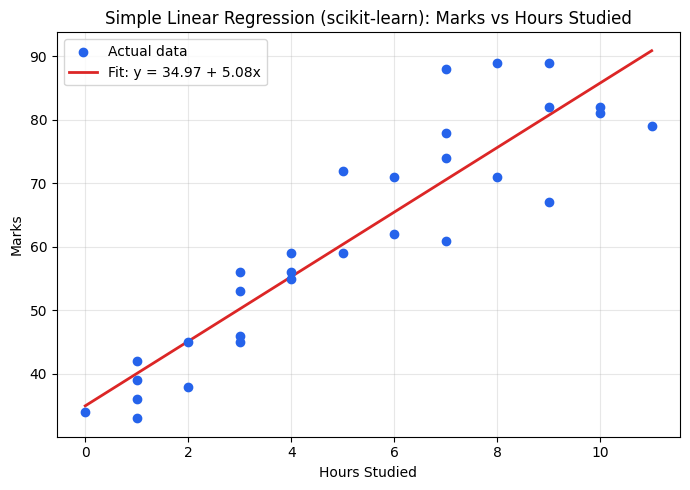

Step 8: Plot saved as regression_plot_sklearn.png


In [ ]:
# STEP 8: Plot the data and regression line
plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='#2563eb', label='Actual data', zorder=3)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model_full.predict(x_line)
plt.plot(x_line, y_line, color='#dc2626', linewidth=2,
         label=f'Fit: y = {model_full.intercept_:.2f} + {model_full.coef_[0]:.2f}x')

plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Simple Linear Regression (scikit-learn): Marks vs Hours Studied')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('regression_plot_sklearn.png', dpi=150)
plt.show()

print("Step 8: Plot saved as regression_plot_sklearn.png")
